# graph analysis

# to remove

In [ ]:
import json

def load_json(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    return data


def get_user_friends(stalked_user, friends_list):
    filter_friend = [ (a,b) for a,b in friends_list if a==stalked_user or b==stalked_user]
    return filter_friend


def get_friends_club(club, friends_list):
    edges = [(a, b) for a, b in friends_list if (a in club) and (b in club)]
    return edges

def get_common_friends(user1, user2, friends_list):
    user1_friends = {b for a, b in friends_list if a == user1} | {a for a, b in friends_list if b == user1}
    user2_friends = {b for a, b in friends_list if a == user2} | {a for a, b in friends_list if b == user2}
    common = user1_friends.intersection(user2_friends)
    return list(common)


def deep_common_friends(club, friends_list):
    commons = []
    for a in club:
        for b in club:
            if a != b:
                commons.extend(get_common_friends(a, b, friends_list))
    return commons

In [2]:
main_data = load_json('my_data.json')
print(len(main_data['users_ids']))
print(len(main_data['main_users']))
print(len(main_data['friends_list']))
print(len(main_data['users_info']))

44530
221
91245
192


In [23]:
filtered_friends = [] 
boss_friends = ['lorenzo_gallinaro', 
                '_martabanfi', 
                'gioele_carlini', 
                'fede.rausa', 
                'beatriceebaroni',
                'alby_greek', 
                'fede.rausa',
                'ilariem',
                ]

for user in boss_friends:
    user_friends = get_user_friends(user, main_data['friends_list'])
    filtered_friends.extend(user_friends)

common_friends = get_common_friends(boss_friends[0], boss_friends[1], main_data['friends_list'])
print(common_friends)

club_friends0 = get_friends_club(common_friends + boss_friends, main_data['friends_list'])
print(club_friends0)


#boss_friends = ['lorenzo_gallinaro', '_martabanfi']

common_friends = deep_common_friends(boss_friends, main_data['friends_list'])
print(common_friends)
club_friends = get_friends_club(common_friends + boss_friends, main_data['friends_list'])
print(club_friends)


['casta_teo_bose', 'francescoomeroni', 'benet2_spaziogiovani', 'beatriceebaroni', 'jackranco', 'fabrizio_alcibiade', 'gioele_carlini', 'fede.rausa', 'nicho.mko', 'alby_greek', 'lucadonati.28', 'tommasoboselli']
[('francescoomeroni', 'fede.rausa'), ('beatriceebaroni', 'fede.rausa'), ('fabrizio_alcibiade', 'fede.rausa'), ('jackranco', 'fede.rausa'), ('lucadonati.28', 'fede.rausa'), ('alby_greek', 'fede.rausa'), ('nicho.mko', 'fede.rausa'), ('lorenzo_gallinaro', 'fede.rausa'), ('gioele_carlini', 'fede.rausa'), ('_martabanfi', 'fede.rausa'), ('benet2_spaziogiovani', 'fede.rausa'), ('francescoomeroni', 'fede.rausa'), ('beatriceebaroni', 'fede.rausa'), ('fabrizio_alcibiade', 'fede.rausa'), ('jackranco', 'fede.rausa'), ('nicho.mko', 'fede.rausa'), ('lucadonati.28', 'fede.rausa'), ('tommasoboselli', 'fede.rausa'), ('lorenzo_gallinaro', 'fede.rausa'), ('alby_greek', 'fede.rausa'), ('gioele_carlini', 'fede.rausa'), ('_martabanfi', 'fede.rausa'), ('fede.rausa', 'lucadonati.28'), ('_martabanfi', '

In [13]:
help(g.layout)

Help on method _layout in module igraph.layout:

_layout(layout=None, *args, **kwds) method of igraph.Graph instance
    Returns the layout of the graph according to a layout algorithm.
    
    Parameters and keyword arguments not specified here are passed to the
    layout algorithm directly. See the documentation of the layout
    algorithms for the explanation of these parameters.
    
    Registered layout names understood by this method are:
    
      - C{auto}, C{automatic}: automatic layout
        (see L{Graph.layout_auto})
    
      - C{bipartite}: bipartite layout (see L{GraphBase.layout_bipartite})
    
      - C{circle}, C{circular}: circular layout
        (see L{GraphBase.layout_circle})
    
      - C{dh}, C{davidson_harel}: Davidson-Harel layout (see
        L{GraphBase.layout_davidson_harel})
    
      - C{drl}: DrL layout for large graphs (see L{GraphBase.layout_drl})
    
      - C{drl_3d}: 3D DrL layout for large graphs
        (see L{GraphBase.layout_drl})
    

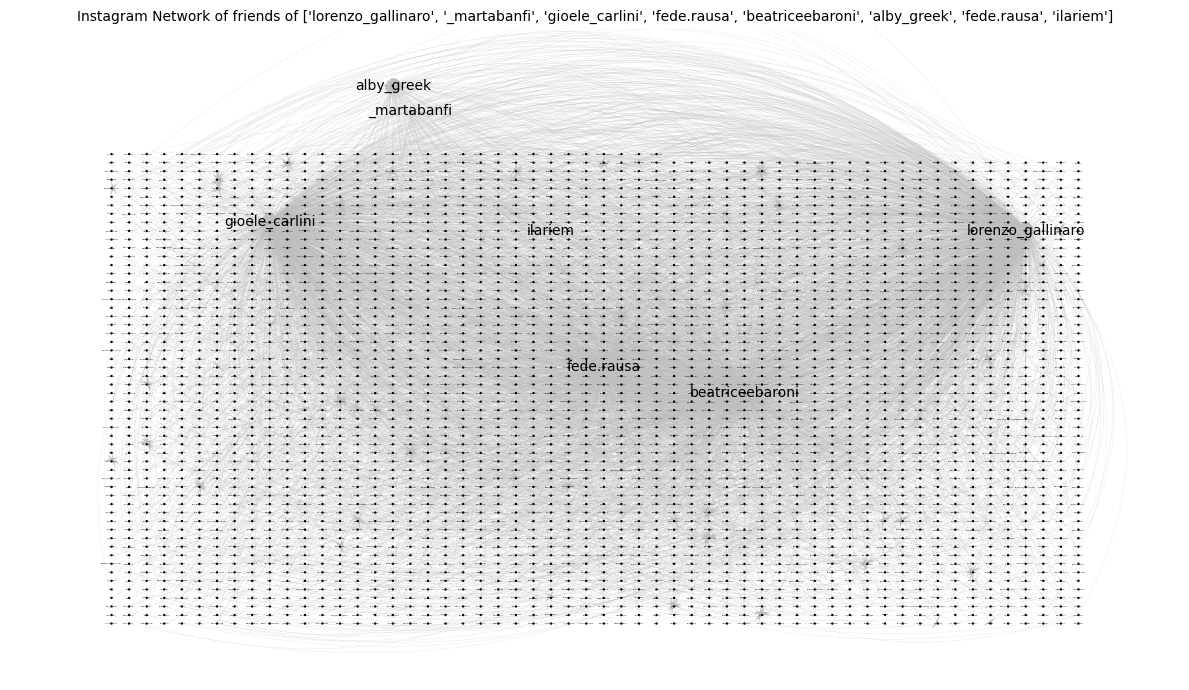

In [36]:
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np

# Example list of directed connections
#edges = main_data['friends_list']#[('mary', 'paul'), ('marcus', 'paul')]


A = 0

if bool(A):
    edges = club_friends
else:  
    edges =  filtered_friends


# Extract the list of unique usernames (vertices)
vertices = list(set([v for edge in edges for v in edge]))

# Create a directed graph
g = ig.Graph(directed=True)
g.add_vertices(vertices)
g.add_edges(edges)


layout = g.layout('grid')  #fr  Fruchterman-Reingold layout #"kk" = Kamada-Kawai layout  # "drl" = Distributed Recursive Layout
coords = layout.coords


if bool(A):
    g.vs["label_family"] = "sans"  # can be "serif", "sans", or "monospace"
    g.es["width"] = 0.1
    g.es["color"] = "gray"
    g.es["arrow_size"] = 2
    g.vs["label_size"] = 7  # font size in points

    # Basic vertex and edge styles
    g.vs["label"] = g.vs["name"]
    g.vs["color"] = "lightblue"
    g.vs["size"] = 1

else:
    g.vs["label_family"] = "sans"  # can be "serif", "sans", or "monospace"
    g.es["width"] = 0.05
    g.es["color"] = "gray"
    g.es["arrow_size"] = 2
    g.vs["label_size"] = [10 if name in boss_friends else 0 for name in g.vs["name"]]

    # Basic vertex and edge styles
    g.vs["label"] = g.vs["name"]
    g.vs["color"] = "lightblue"
    g.vs["size"] = 1


# 🎨 Label font settings
g.vs["label_color"] = "black"


   


if not bool(A):

    label_offsets = {u : (0, 15) for u in boss_friends}

    # Apply manual label offsets
    for i, name in enumerate(g.vs["name"]):
        if name in label_offsets:
            dx, dy = label_offsets[name]
            coords[i] = (coords[i][0] + dx, coords[i][1] + dy)

else:
    if bool(1):
        label_offsets = {u : (0, np.random.uniform(-0.4, 0.4)) for u in g.vs["name"]}

        # Apply manual label offsets
        for i, name in enumerate(g.vs["name"]):
            if name in label_offsets:
                dx, dy = label_offsets[name]
                coords[i] = (coords[i][0] + dx, coords[i][1] + dy)


# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the graph
ig.plot(g,layout=coords, target=ax)

plt.title(f"Instagram Network of friends of {boss_friends}", fontsize=10)
plt.tight_layout()
plt.show()

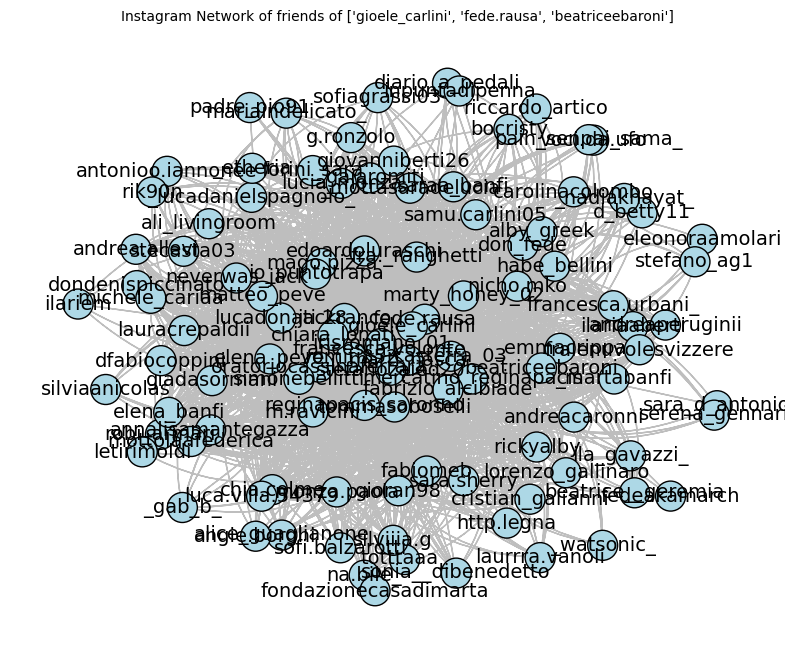

In [29]:
import igraph as ig
import matplotlib.pyplot as plt

# Your list of tuples
#edges = [('mary', 'paul'), ('marcus', 'paul')]
edges = club_friends0

# Create a directed graph
g = ig.Graph(directed=True)

# Add all unique vertices (nodes)
all_vertices = set()
for edge in edges:
    all_vertices.add(edge[0])
    all_vertices.add(edge[1])

vertices_list = list(all_vertices)
g.add_vertices(vertices_list)

# Add edges
edge_list = [(vertices_list.index(edge[0]), vertices_list.index(edge[1])) for edge in edges]
g.add_edges(edge_list)

# Set visual style
visual_style = {
    "vertex_size": 30,
    "vertex_color": "lightblue",
    "vertex_label": vertices_list,
    "vertex_label_size": 14,
    "edge_color": "gray",
    "edge_arrow_size": 1.0,
    "edge_arrow_width": 1.0,
    "edge_width": 1,
    "layout": g.layout("kk"),  # Kamada-Kawai layout
    "bbox": (400, 300),
    "margin": 50
}


# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))


# Plot the graph

ig.plot(g, target=ax, **visual_style)

plt.title(f"Instagram Network of friends of {boss_friends}", fontsize=10)
#plt.tight_layout()
plt.show()

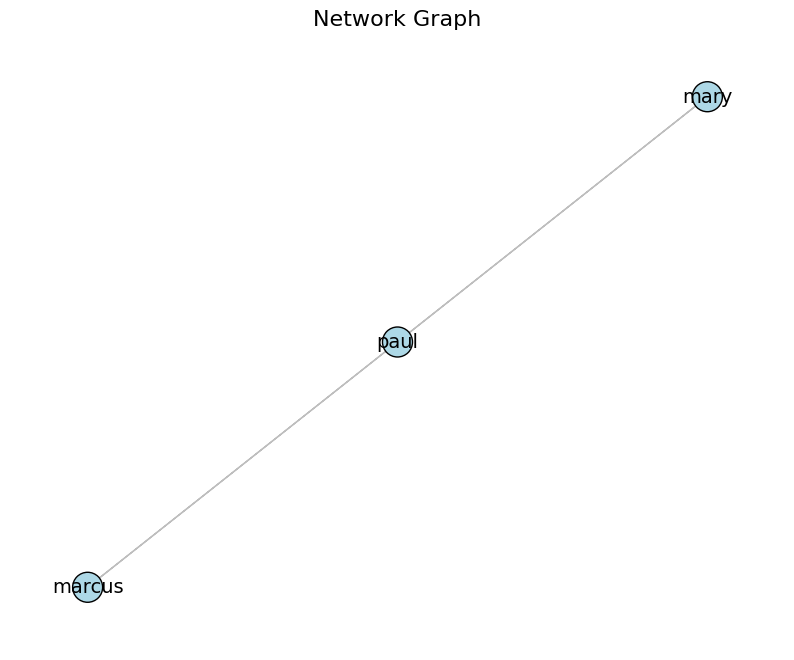

In [8]:
import igraph as ig
import matplotlib.pyplot as plt

# Your list of tuples
edges = [('mary', 'paul'), ('marcus', 'paul')]

# Create a directed graph
g = ig.Graph(directed=True)

# Add all unique vertices (nodes)
all_vertices = set()
for edge in edges:
    all_vertices.add(edge[0])
    all_vertices.add(edge[1])

vertices_list = list(all_vertices)
g.add_vertices(vertices_list)

# Add edges
edge_list = [(vertices_list.index(edge[0]), vertices_list.index(edge[1])) for edge in edges]
g.add_edges(edge_list)

# Set visual style
visual_style = {
    "vertex_size": 30,
    "vertex_color": "lightblue",
    "vertex_label": vertices_list,
    "vertex_label_size": 14,
    "edge_color": "gray",
    "edge_arrow_size": 1.0,
    "edge_arrow_width": 1.0,
    "edge_width": 1,
    "layout": g.layout("kk"),  # Kamada-Kawai layout
    "bbox": (400, 300),
    "margin": 50
}


# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))


# Plot the graph

ig.plot(g, target=ax, **visual_style)

plt.title("Network Graph", fontsize=16)
#plt.tight_layout()
plt.show()

# pyvis

In [38]:
from pyvis.network import Network

# Your list of tuples (follower -> followed)
edges = [('A', 'B'), ('B', 'C'), ('A', 'D'), ('C', 'D'), ('D', 'E')]

# Create a PyVis Network
net = Network(height="750px", width="100%", directed=True, notebook=False)

# Add edges and nodes
for source, target in edges:
    net.add_node(source, label=source)
    net.add_node(target, label=target)
    net.add_edge(source, target)

# Enable physics and other default options
net.toggle_physics(True)
net.show_buttons(filter_=['physics'])  # built-in PyVis control panel

# Save the graph as HTML
net.show("interactive_follow_graph.html")

print("✅ Graph saved to interactive_follow_graph.html")


interactive_follow_graph.html


AttributeError: 'NoneType' object has no attribute 'render'

In [41]:
from pyvis.network import Network

edges = club_friends#filtered_friends#[('A', 'B'), ('B', 'C')]

net = Network(height="700px", width="100%", directed=True)
for a, b in edges:
    net.add_node(a)
    net.add_node(b)
    net.add_edge(a, b)

# Generate HTML file without showing immediately
net.write_html("custom_ui_graph.html")

# Inject UI controls
custom_ui = """
<script>
function setPhysics(enabled) {
    network.setOptions({ physics: { enabled: enabled } });
}
function setLayout(type) {
    if (type === 'hierarchical') {
        network.setOptions({ layout: { hierarchical: { enabled: true } } });
    } else {
        network.setOptions({ layout: { hierarchical: { enabled: false } } });
    }
}
</script>

<div style="padding:10px;">
    <button onclick="setPhysics(true)">Enable Physics</button>
    <button onclick="setPhysics(false)">Disable Physics</button>
    <button onclick="setLayout('hierarchical')">Hierarchical Layout</button>
    <button onclick="setLayout('default')">Default Layout</button>
</div>
"""

# Insert UI above the graph div
with open("custom_ui_graph.html", "r+", encoding="utf-8") as f:
    html = f.read().replace("<body>", "<body>\n" + custom_ui)
    f.seek(0)
    f.write(html)
    f.truncate()

print("✅ Graph with custom UI saved to custom_ui_graph.html")


✅ Graph with custom UI saved to custom_ui_graph.html


In [42]:
import json
from pyvis.network import Network

# Your data
edges = [
    ('A', 'B'), ('B', 'C'), ('C', 'D'),
    ('A', 'D'), ('E', 'A'), ('F', 'A'), ('C', 'E')
]

# Build adjacency list for each user
from collections import defaultdict
friends = defaultdict(set)
for a, b in edges:
    friends[a].add(b)
    friends[b].add(a)  # undirected friendship for demo; remove if one-way

# Prepare HTML/JS data
users = sorted(friends.keys())
edges_json = json.dumps(edges)
users_json = json.dumps(users)

# Base HTML template
html_template = f"""
<!DOCTYPE html>
<html>
<head>
  <title>Interactive Friend Graph</title>
  <script type="text/javascript" src="https://unpkg.com/vis-network@9.1.2/dist/vis-network.min.js"></script>
  <link href="https://unpkg.com/vis-network@9.1.2/dist/vis-network.min.css" rel="stylesheet" type="text/css" />
  <style>
    body {{
      font-family: sans-serif;
      display: flex;
      flex-direction: row;
      gap: 20px;
      margin: 0;
      padding: 20px;
    }}
    #controls {{
      width: 220px;
      overflow-y: auto;
      border-right: 1px solid #ccc;
      padding-right: 10px;
    }}
    #mynetwork {{
      flex-grow: 1;
      height: 90vh;
      border: 1px solid #ddd;
      border-radius: 10px;
    }}
  </style>
</head>
<body>

<div id="controls">
  <h3>Select users</h3>
  <div id="user-list"></div>
</div>

<div id="mynetwork"></div>

<script type="text/javascript">
  const allEdges = {edges_json};
  const users = {users_json};

  // Build adjacency
  const adjacency = {{}};
  allEdges.forEach(([a, b]) => {{
    if (!adjacency[a]) adjacency[a] = [];
    if (!adjacency[b]) adjacency[b] = [];
    adjacency[a].push(b);
    adjacency[b].push(a); // comment if directed
  }});

  // Initialize vis.js datasets
  const nodes = new vis.DataSet([]);
  const edges = new vis.DataSet([]);

  const container = document.getElementById('mynetwork');
  const network = new vis.Network(container, {{ nodes, edges }}, {{
    physics: {{ enabled: true }},
    interaction: {{ hover: true }},
  }});

  // Function to add user and their friends
  function addUserAndFriends(user) {{
    if (!adjacency[user]) return;
    if (!nodes.get(user)) {{
      nodes.add({{ id: user, label: user }});
    }}
    adjacency[user].forEach(friend => {{
      if (!nodes.get(friend)) {{
        nodes.add({{ id: friend, label: friend }});
      }}
      const existing = edges.get({{ filter: e => (e.from === user && e.to === friend) || (e.from === friend && e.to === user) }});
      if (existing.length === 0) {{
        edges.add({{ from: user, to: friend }});
      }}
    }});
  }}

  // Function to remove user and their edges
  function removeUser(user) {{
    const connectedEdges = edges.get({{ filter: e => e.from === user || e.to === user }});
    connectedEdges.forEach(e => edges.remove(e.id));
    nodes.remove(user);
  }}

  // Build checkbox UI
  const list = document.getElementById('user-list');
  users.forEach(u => {{
    const div = document.createElement('div');
    const cb = document.createElement('input');
    cb.type = 'checkbox';
    cb.id = u;
    cb.onchange = () => {{
      if (cb.checked) addUserAndFriends(u);
      else removeUser(u);
    }};
    const label = document.createElement('label');
    label.htmlFor = u;
    label.textContent = ' ' + u;
    div.appendChild(cb);
    div.appendChild(label);
    list.appendChild(div);
  }});
</script>

</body>
</html>
"""

# Save to file
with open("user_select_graph.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("✅ Saved to user_select_graph.html — open it in a browser!")


✅ Saved to user_select_graph.html — open it in a browser!


In [43]:
import json
from collections import defaultdict

# Example edges (directed or undirected, depending on your use case)
edges = [
    ('A', 'B'), ('B', 'C'), ('C', 'D'),
    ('A', 'D'), ('E', 'A'), ('F', 'A'), ('C', 'E')
]

# Build adjacency list
friends = defaultdict(set)
for a, b in edges:
    friends[a].add(b)
    friends[b].add(a)  # remove this line if you want directed

# Prepare JSON data for embedding
users = sorted(friends.keys())
edges_json = json.dumps(edges)
users_json = json.dumps(users)

# HTML Template
html_template = f"""
<!DOCTYPE html>
<html>
<head>
  <title>Interactive Friend Graph</title>
  <script type="text/javascript" src="https://unpkg.com/vis-network@9.1.2/dist/vis-network.min.js"></script>
  <link href="https://unpkg.com/vis-network@9.1.2/dist/vis-network.min.css" rel="stylesheet" type="text/css" />
  <style>
    body {{
      font-family: sans-serif;
      display: flex;
      flex-direction: row;
      gap: 20px;
      margin: 0;
      padding: 20px;
    }}
    #controls {{
      width: 240px;
      overflow-y: auto;
      border-right: 1px solid #ccc;
      padding-right: 10px;
    }}
    #mynetwork {{
      flex-grow: 1;
      height: 90vh;
      border: 1px solid #ddd;
      border-radius: 10px;
    }}
    button {{
      margin: 4px 0;
      padding: 5px 10px;
      border-radius: 6px;
      border: 1px solid #888;
      background: #f8f8f8;
      cursor: pointer;
    }}
    button:hover {{
      background: #eee;
    }}
  </style>
</head>
<body>

<div id="controls">
  <h3>Select users</h3>
  <div id="user-list"></div>
  <hr>
  <h4>Physics</h4>
  <button onclick="enablePhysics()">Enable Physics</button>
  <button onclick="disablePhysics()">Disable Physics</button>
</div>

<div id="mynetwork"></div>

<script type="text/javascript">
  const allEdges = {edges_json};
  const users = {users_json};

  // Build adjacency
  const adjacency = {{}};
  allEdges.forEach(([a, b]) => {{
    if (!adjacency[a]) adjacency[a] = [];
    if (!adjacency[b]) adjacency[b] = [];
    adjacency[a].push(b);
    adjacency[b].push(a); // remove if directed
  }});

  // Initialize datasets
  const nodes = new vis.DataSet([]);
  const edges = new vis.DataSet([]);

  const container = document.getElementById('mynetwork');
  const network = new vis.Network(container, {{ nodes, edges }}, {{
    physics: {{ enabled: false }}, // 🚫 physics disabled initially
    interaction: {{ hover: true }},
  }});

  // Functions to control physics
  function enablePhysics() {{
    network.setOptions({{ physics: {{ enabled: true }} }});
  }}
  function disablePhysics() {{
    network.setOptions({{ physics: {{ enabled: false }} }});
  }}

  // Function to add user and their friends
  function addUserAndFriends(user) {{
    if (!adjacency[user]) return;
    if (!nodes.get(user)) {{
      nodes.add({{ id: user, label: user }});
    }}
    adjacency[user].forEach(friend => {{
      if (!nodes.get(friend)) {{
        nodes.add({{ id: friend, label: friend }});
      }}
      const existing = edges.get({{ filter: e => (e.from === user && e.to === friend) || (e.from === friend && e.to === user) }});
      if (existing.length === 0) {{
        edges.add({{ from: user, to: friend }});
      }}
    }});
  }}

  // Function to remove user and their edges
  function removeUser(user) {{
    const connectedEdges = edges.get({{ filter: e => e.from === user || e.to === user }});
    connectedEdges.forEach(e => edges.remove(e.id));
    nodes.remove(user);
  }}

  // Build checkbox UI
  const list = document.getElementById('user-list');
  users.forEach(u => {{
    const div = document.createElement('div');
    const cb = document.createElement('input');
    cb.type = 'checkbox';
    cb.id = u;
    cb.onchange = () => {{
      if (cb.checked) addUserAndFriends(u);
      else removeUser(u);
    }};
    const label = document.createElement('label');
    label.htmlFor = u;
    label.textContent = ' ' + u;
    div.appendChild(cb);
    div.appendChild(label);
    list.appendChild(div);
  }});
</script>

</body>
</html>
"""

# Save to file
with open("user_select_graph_physics_off.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("✅ Saved to user_select_graph_physics_off.html — open it in your browser!")


✅ Saved to user_select_graph_physics_off.html — open it in your browser!


In [44]:
import json
from collections import defaultdict

edges = [
    ('A', 'B'), ('B', 'C'), ('C', 'D'),
    ('A', 'D'), ('E', 'A'), ('F', 'A'), ('C', 'E')
]

friends = defaultdict(set)
for a, b in edges:
    friends[a].add(b)
    friends[b].add(a)  # remove if directed

users = sorted(friends.keys())
edges_json = json.dumps(edges)
users_json = json.dumps(users)

html_template = f"""
<!DOCTYPE html>
<html>
<head>
  <title>Interactive Friend Graph</title>
  <script src="https://unpkg.com/vis-network@9.1.2/dist/vis-network.min.js"></script>
  <link href="https://unpkg.com/vis-network@9.1.2/dist/vis-network.min.css" rel="stylesheet" />
  <style>
    body {{
      font-family: sans-serif;
      display: flex;
      flex-direction: row;
      gap: 20px;
      margin: 0;
      padding: 20px;
    }}
    #controls {{
      width: 240px;
      overflow-y: auto;
      border-right: 1px solid #ccc;
      padding-right: 10px;
    }}
    #mynetwork {{
      flex-grow: 1;
      height: 90vh;
      border: 1px solid #ddd;
      border-radius: 10px;
    }}
    button {{
      margin: 4px 0;
      padding: 5px 10px;
      border-radius: 6px;
      border: 1px solid #888;
      background: #f8f8f8;
      cursor: pointer;
    }}
    button:hover {{
      background: #eee;
    }}
  </style>
</head>
<body>

<div id="controls">
  <h3>Select users</h3>
  <div id="user-list"></div>
  <hr>
  <h4>Physics</h4>
  <button onclick="enablePhysics()">Enable Physics</button>
  <button onclick="disablePhysics()">Disable Physics</button>
</div>

<div id="mynetwork"></div>

<script>
  const allEdges = {edges_json};
  const users = {users_json};

  // Build adjacency
  const adjacency = {{}};
  allEdges.forEach(([a,b]) => {{
    if (!adjacency[a]) adjacency[a] = [];
    if (!adjacency[b]) adjacency[b] = [];
    adjacency[a].push(b);
    adjacency[b].push(a); // remove if directed
  }});

  // Data sets
  const nodes = new vis.DataSet([]);
  const edges = new vis.DataSet([]);
  const container = document.getElementById('mynetwork');
  const network = new vis.Network(container, {{ nodes, edges }}, {{
    physics: {{ enabled: false }},
    interaction: {{ hover: true }},
  }});

  function enablePhysics() {{
    network.setOptions({{ physics: {{ enabled: true }} }});
  }}
  function disablePhysics() {{
    network.setOptions({{ physics: {{ enabled: false }} }});
  }}

  // --- Layout helper: place nodes in a circle around origin ---
  function placeNode(nodeId, index, total, radius = 150) {{
    const angle = (index / total) * 2 * Math.PI;
    return {{
      id: nodeId,
      label: nodeId,
      x: Math.cos(angle) * radius,
      y: Math.sin(angle) * radius
    }};
  }}

  function addUserAndFriends(user) {{
    if (!adjacency[user]) return;

    const total = Object.keys(adjacency[user]).length + 1;
    let index = 0;

    // Add main user in center if not exists
    if (!nodes.get(user)) {{
      nodes.add({{ id: user, label: user, x: 0, y: 0, fixed: true }});
    }}

    // Add each friend in circular layout around main user
    adjacency[user].forEach(friend => {{
      if (!nodes.get(friend)) {{
        const pos = placeNode(friend, index++, total);
        nodes.add({{ ...pos, fixed: true }});
      }}
      const existing = edges.get({{ filter: e => (e.from === user && e.to === friend) || (e.from === friend && e.to === user) }});
      if (existing.length === 0) {{
        edges.add({{ from: user, to: friend }});
      }}
    }});
  }}

  function removeUser(user) {{
    const connectedEdges = edges.get({{ filter: e => e.from === user || e.to === user }});
    connectedEdges.forEach(e => edges.remove(e.id));
    nodes.remove(user);
  }}

  // UI checkboxes
  const list = document.getElementById('user-list');
  users.forEach(u => {{
    const div = document.createElement('div');
    const cb = document.createElement('input');
    cb.type = 'checkbox';
    cb.id = u;
    cb.onchange = () => {{
      if (cb.checked) addUserAndFriends(u);
      else removeUser(u);
    }};
    const label = document.createElement('label');
    label.htmlFor = u;
    label.textContent = ' ' + u;
    div.appendChild(cb);
    div.appendChild(label);
    list.appendChild(div);
  }});
</script>

</body>
</html>
"""

with open("user_select_graph_static_layout.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("✅ Saved to user_select_graph_static_layout.html — open it in your browser!")


✅ Saved to user_select_graph_static_layout.html — open it in your browser!


In [55]:
# pip install pyvis
import math
import json
from pyvis.network import Network

# -------------------------
# Example data (replace with your own)
# -------------------------
edges = [
    ('A', 'B'), ('B', 'C'), ('C', 'D'),
    ('A', 'D'), ('E', 'A'), ('F', 'A'), ('C', 'E'),
    ('G', 'H'), ('H', 'I'), ('I', 'J'), ('J', 'K'),
    ('L', 'M'), ('M', 'N'), ('N', 'O')
]

# -------------------------
# Build node list and positions (grid layout)
# -------------------------
nodes = sorted({n for e in edges for n in e})
N = len(nodes)

# grid dimensions
cols = int(math.ceil(math.sqrt(N)))
rows = int(math.ceil(N / cols))
spacing = 140  # px spacing between nodes (tune this)

positions = {}
for idx, node in enumerate(nodes):
    r = idx // cols
    c = idx % cols
    # center the grid around (0,0)
    x = (c - (cols - 1) / 2.0) * spacing
    y = (r - (rows - 1) / 2.0) * spacing
    positions[node] = (x, y)

# -------------------------
# Create PyVis Network
# -------------------------
net = Network(
    height="800px",
    width="100%",
    directed=True,   # set False if you want undirected
    notebook=False,  # set True if you're in a notebook and want inline display
)

# Add nodes with fixed coordinates to avoid center pile-up when physics = False
for node in nodes:
    x, y = positions[node]
    net.add_node(node, label=str(node), x=int(x), y=int(y), fixed=True)

# Add edges
for a, b in edges:
    net.add_edge(a, b)

# -------------------------
# Build vis.js options (as Python dict) and set via net.set_options
# -------------------------
options = {
    "physics": {
        "enabled": False   # physics OFF initially (faster), user can toggle later
    },
    "layout": {
        "improvedLayout": True
    },
    "interaction": {
        "hover": True,
        "multiselect": True,
        "navigationButtons": True
    },
    "nodes": {
        "shape": "dot",
        "size": 14,
        "font": {"size": 14}
    },
    "edges": {
        "arrows": {"to": {"enabled": True, "scaleFactor": 0.6}},
        "smooth": {"enabled": True, "type": "dynamic"}
    }
}

# PyVis expects a JS snippet string; wrapping as 'var options = ...;' is robust.
#options_js = "var options = " + json.dumps(options, indent=2) + ";"
net.set_options(json.dumps(options))


# -------------------------
# Export HTML file and also capture HTML into a Python string
# -------------------------
out_filename = "graph_with_options.html"
net.write_html(out_filename)


extra_js = """
<script>
  // Recreate vis.js configure panel
  var options = network.getOptionsFromConfigurator();
  var configurator = new vis.Configurator(network, options);
  configurator.show();
</script>
"""
with open(out_filename, "r+", encoding="utf-8") as f:
    html = f.read().replace("</body>", extra_js + "\n</body>")
    f.seek(0)
    f.write(html)
    f.truncate()


# read back the HTML into a string variable (useful for embedding in Flask/Django templates, or Jupyter)
with open(out_filename, "r", encoding="utf-8") as f:
    html = f.read()

print(f"Saved: {out_filename}")
# 'html' now contains the full HTML text. You can return it from a Flask view,
# embed it into an iframe, render it in a Jupyter display(HTML(html)), etc.


Saved: graph_with_options.html


In [52]:
import math, json
from pyvis.network import Network

edges = [
    ('A', 'B'), ('B', 'C'), ('C', 'D'),
    ('A', 'D'), ('E', 'A'), ('F', 'A'), ('C', 'E'),
]

nodes = sorted({n for e in edges for n in e})
cols = int(math.ceil(math.sqrt(len(nodes))))
spacing = 150
positions = {}
for i, node in enumerate(nodes):
    r, c = divmod(i, cols)
    positions[node] = (c * spacing, r * spacing)

net = Network(height="700px", width="100%", directed=True)

for n in nodes:
    x, y = positions[n]
    net.add_node(n, label=n, x=x, y=y, fixed=True)
for a, b in edges:
    net.add_edge(a, b)

# Set default options
options = {
    "physics": {"enabled": False},
    "interaction": {"hover": True, "navigationButtons": True},
    "nodes": {"shape": "dot", "size": 15, "font": {"size": 14}},
    "edges": {"arrows": {"to": {"enabled": True}}, "smooth": False},
}
net.set_options(json.dumps(options))



# ✅ Add the vis.js built-in UI panel
net.show_buttons(filter_=['physics', 'layout', 'interaction', 'manipulation'])

net.show("graph_with_ui.html")
print("✅ Graph saved to graph_with_ui.html — open it in your browser")


FileNotFoundError: [Errno 2] No such file or directory: 'graph.html'

In [56]:
from pyvis.network import Network

# Your follower data: (follower, followed)
followers = [('A', 'B'), ('B', 'C')]

# Create network graph
net = Network(height='750px', width='100%', bgcolor='#222222', font_color='white')

# Add nodes and edges from the tuples
for follower, followed in followers:
    net.add_node(follower, label=follower, title=f'User: {follower}')
    net.add_node(followed, label=followed, title=f'User: {followed}')
    # Add directed edge (follower -> followed)
    net.add_edge(follower, followed, title=f'{follower} follows {followed}')

# Enable physics for interactive layout
net.toggle_physics(True)

# Show configuration UI - allows tweaking graph options in the browser
net.show_buttons(filter_=['physics', 'nodes', 'edges'])

# Save and display
net.save_graph('follower_network.html')
print("Graph saved as 'follower_network.html'. Open it in your browser!")

Graph saved as 'follower_network.html'. Open it in your browser!


In [58]:
from pyvis.network import Network


############################################## BLOCK1
# Your follower data: (follower, followed)
followers = club_friends#[('A', 'B'), ('B', 'C')]

# Create network graph
net = Network(height='750px', width='100%', bgcolor='#222222', font_color='white')

# Add nodes and edges from the tuples
for follower, followed in followers:
    net.add_node(follower, label=follower, title=f'User: {follower}')
    net.add_node(followed, label=followed, title=f'User: {followed}')
    # Add directed edge (follower -> followed)
    net.add_edge(follower, followed, title=f'{follower} follows {followed}')

# Enable physics for interactive layout
net.toggle_physics(False)

# Show configuration UI - allows tweaking graph options in the browser
net.show_buttons(filter_=['physics', 'nodes', 'edges'])

# Save the graph
net.save_graph('follower_network.html')

########################################################################################### BLOCK2


# Modify the HTML to position config panel on the right side
with open('follower_network.html', 'r', encoding='utf-8') as f:
    html = f.read()

# Add custom CSS to position the config panel on the right
custom_css = """
<style>
#config {
    position: fixed !important;
    right: 10px !important;
    top: 10px !important;
    left: auto !important;
    max-height: 90vh !important;
    overflow-y: auto !important;
    z-index: 1000 !important;
}
#mynetwork {
    margin-right: 320px !important;
}
</style>
"""

# Insert the CSS before </head>
html = html.replace('</head>', custom_css + '</head>')

with open('follower_network.html', 'w', encoding='utf-8') as f:
    f.write(html)
print("Graph saved as 'follower_network.html'. Open it in your browser!")

Graph saved as 'follower_network.html'. Open it in your browser!


In [7]:
from pyvis.network import Network
import json

# Your follower data: (follower, followed)
followers = main_data['friends_list']#[('A', 'B'), ('B', 'C'), ('C', 'D'), ('A', 'D')]

# Main users to filter
main_users = main_data['main_users']#['A', 'B']

# Create network graph (initially empty)
net = Network(height='750px', width='100%', bgcolor='#222222', font_color='white')

# Enable physics for interactive layout
net.toggle_physics(False)

# Show configuration UI
net.show_buttons(filter_=['physics', 'nodes', 'edges'])

# Save the initial graph
net.save_graph('follower_network.html')

# Build a map of user connections for quick lookup
user_connections = {}
for follower, followed in followers:
    if follower not in user_connections:
        user_connections[follower] = {'follows': [], 'followed_by': []}
    if followed not in user_connections:
        user_connections[followed] = {'follows': [], 'followed_by': []}
    user_connections[follower]['follows'].append(followed)
    user_connections[followed]['followed_by'].append(follower)

# Modify the HTML to add custom checkbox UI
with open('follower_network.html', 'r', encoding='utf-8') as f:
    html = f.read()

# Create checkbox HTML
checkbox_html = '<div id="user-filter"><h3>Filter by Main Users</h3>'
for user in main_users:
    checkbox_html += f'<label><input type="checkbox" value="{user}" onchange="toggleUser(this)"> {user}</label><br>'
checkbox_html += '</div>'

# Add custom CSS and JavaScript
custom_code = f"""
<style>
#config {{
    position: fixed !important;
    right: 10px !important;
    top: 10px !important;
    left: auto !important;
    max-height: 90vh !important;
    overflow-y: auto !important;
    z-index: 1000 !important;
}}
#user-filter {{
    position: fixed !important;
    left: 10px !important;
    top: 10px !important;
    background: #333 !important;
    color: white !important;
    padding: 15px !important;
    border-radius: 5px !important;
    box-shadow: 0 2px 10px rgba(0,0,0,0.3) !important;
    z-index: 1000 !important;
    max-height: 90vh !important;
    overflow-y: auto !important;
}}
#user-filter h3 {{
    margin-top: 0;
    margin-bottom: 10px;
}}
#user-filter label {{
    display: block;
    margin: 5px 0;
    cursor: pointer;
}}
#mynetwork {{
    margin-right: 320px !important;
    margin-left: 200px !important;
}}
</style>
{checkbox_html}
<script>
const allFollowers = {json.dumps(followers)};
const userConnections = {json.dumps(user_connections)};
const activeUsers = new Set();

function getUserFriends(user) {{
    const friends = new Set();
    const connections = userConnections[user] || {{}};
    
    // Add who this user follows
    if (connections.follows) {{
        connections.follows.forEach(f => friends.add(f));
    }}
    
    // Add who follows this user
    if (connections.followed_by) {{
        connections.followed_by.forEach(f => friends.add(f));
    }}
    
    return friends;
}}

function toggleUser(checkbox) {{
    const user = checkbox.value;
    
    if (checkbox.checked) {{
        activeUsers.add(user);
    }} else {{
        activeUsers.delete(user);
    }}
    
    updateGraph();
}}

function updateGraph() {{
    // Clear the network
    network.body.data.nodes.clear();
    network.body.data.edges.clear();
    
    if (activeUsers.size === 0) {{
        return; // Keep graph empty
    }}
    
    const nodesToShow = new Set();
    const edgesToShow = [];
    
    // For each active main user, get them and their friends
    activeUsers.forEach(mainUser => {{
        nodesToShow.add(mainUser);
        const friends = getUserFriends(mainUser);
        friends.forEach(friend => nodesToShow.add(friend));
    }});
    
    // Add edges that involve the nodes we're showing
    allFollowers.forEach(([follower, followed]) => {{
        if (nodesToShow.has(follower) && nodesToShow.has(followed)) {{
            edgesToShow.push({{from: follower, to: followed}});
        }}
    }});
    
    // Add nodes to network
    const nodes = Array.from(nodesToShow).map(user => ({{
        id: user,
        label: user,
        title: `User: ${{user}}`
    }}));
    
    network.body.data.nodes.add(nodes);
    network.body.data.edges.add(edgesToShow.map((edge, idx) => ({{
        id: idx,
        from: edge.from,
        to: edge.to,
        arrows: 'to',
        title: `${{edge.from}} follows ${{edge.to}}`
    }})));
    
    network.fit();
}}
</script>
"""

# Insert the custom code before </head>
html = html.replace('</head>', custom_code + '</head>')

with open('follower_network.html', 'w', encoding='utf-8') as f:
    f.write(html)

print("Graph saved as 'follower_network.html'. Open it in your browser!")

Graph saved as 'follower_network.html'. Open it in your browser!


## better follower_network

In [ ]:
from pyvis.network import Network
import json
import networkx as nx

def load_json(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    return data


def networkx2pyvis(netxG, pyvisG):

    # Add nodes with positions from the layout algorithm
    for node in netxG.nodes():
        x, y = pos[node]
        pyvisG.add_node(node, x=x*100, y=y*100, label=str(node))  # Scale positions for better visualization

    # Add edges
    for edge in netxG.edges():
        pyvisG.add_edge(edge[0], edge[1])

    return pyvisG


def get_common_friends(user1, user2, friends_list):
    '''
    Given two users and a list of friendship tuples (friends_list),
    return a list of their common friends.
    '''
    user1_friends = {b for a, b in friends_list if a == user1} | {a for a, b in friends_list if b == user1}
    user2_friends = {b for a, b in friends_list if a == user2} | {a for a, b in friends_list if b == user2}
    common = user1_friends.intersection(user2_friends)
    return list(common)

def deep_common_friends(club, friends_list):
    '''
    Given a list of users (club) and a list of friendship tuples (friends_list),
    return a list of all common friends between every pair of users in the club.
    '''
    commons = []
    for a in club:
        for b in club:
            if a != b:
                commons.extend(get_common_friends(a, b, friends_list))
    return commons


main_data = load_json('my_data.json')

'''
example structure of main_data:
main_data = {
    "main_users": ["A", "B"],
    "friends_list": [("A", "B"), ("B", "C"), ("C", "D"), ("A", "D"), ("E", "A"), ("F", "A"), ("C", "E")]
    "user_info": {
        "A": {"name": "Alice", "age": 30},
        "B": {"name": "Bob", "age": 25}
    }
'''




# Your follower data: (follower, followed)
followers = main_data['friends_list']#[('A', 'B'), ('B', 'C'), ('C', 'D'), ('A', 'D')]

# Main users to filter
main_users = main_data['main_users']#['A', 'B']



selected = ['A', 'B']

only_common = deep_common_friends(selected, followers)








# Create a NetworkX graph
G = nx.Graph()
G.add_edges_from(edges)

# Choose and apply a layout algorithm
# Available algorithms: spring_layout, circular_layout, random_layout, 
# shell_layout, spectral_layout, kamada_kawai_layout, etc.
layout_algorithm = nx.spectral_layout  # You can change this to any layout algorithm
pos = layout_algorithm(G)

# Create Pyvis network
# net = Network(notebook=True, height="500px", width="100%")

# # Disable physics
# net.set_options("""
# var options = {
#   "physics": {
#     "enabled": false
#   }
# }
# """)

# Create network graph (initially empty)
net = Network(height='750px', width='100%', bgcolor='#222222', font_color='white')

# Enable physics for interactive layout
net.toggle_physics(False)

net = networkx2pyvis(G, net)


# Show configuration UI
net.show_buttons(filter_=['physics'])#, 'nodes', 'edges'])

# Save the initial graph
net.save_graph('follower_network.html')

# Build a map of user connections for quick lookup
user_connections = {}
for follower, followed in followers:
    if follower not in user_connections:
        user_connections[follower] = {'follows': [], 'followed_by': []}
    if followed not in user_connections:
        user_connections[followed] = {'follows': [], 'followed_by': []}
    user_connections[follower]['follows'].append(followed)
    user_connections[followed]['followed_by'].append(follower)

# Modify the HTML to add custom checkbox UI
with open('follower_network.html', 'r', encoding='utf-8') as f:
    html = f.read()

##################################### Create checkbox HTML
checkbox_html = '<div id="user-filter"><h3>Filter by Main Users</h3>'
for user in main_users:
    checkbox_html += f'<label><input type="checkbox" value="{user}" onchange="toggleUser(this)"> {user}</label><br>'
checkbox_html += '</div>'



#################################### create CSS

css_code = f"""
<style>
#config {{
    position: fixed !important;
    right: 10px !important;
    top: 10px !important;
    left: auto !important;
    max-height: 90vh !important;
    overflow-y: auto !important;
    z-index: 1000 !important;
}}
#user-filter {{
    position: fixed !important;
    left: 10px !important;
    top: 10px !important;
    background: #333 !important;
    color: white !important;
    padding: 15px !important;
    border-radius: 5px !important;
    box-shadow: 0 2px 10px rgba(0,0,0,0.3) !important;
    z-index: 1000 !important;
    max-height: 90vh !important;
    overflow-y: auto !important;
}}
#user-filter h3 {{
    margin-top: 0;
    margin-bottom: 10px;
}}
#user-filter label {{
    display: block;
    margin: 5px 0;
    cursor: pointer;
}}
#mynetwork {{
    margin-right: 320px !important;
    margin-left: 200px !important;
}}
</style>
"""


################################ create JS code


js_code = f"""
<script>
const allFollowers = {json.dumps(followers)};
const userConnections = {json.dumps(user_connections)};
const activeUsers = new Set();


function getUserFriends(user) {{
    const friends = new Set();
    const connections = userConnections[user] || {{}};
    
    // Add who this user follows
    if (connections.follows) {{
        connections.follows.forEach(f => friends.add(f));
    }}
    
    // Add who follows this user
    if (connections.followed_by) {{
        connections.followed_by.forEach(f => friends.add(f));
    }}
    
    return friends;
}}


function toggleUser(checkbox) {{
    const user = checkbox.value;
    
    if (checkbox.checked) {{
        activeUsers.add(user);
    }} else {{
        activeUsers.delete(user);
    }}
    
    updateGraph();
}}



function updateGraph() {{
    // Clear the network
    network.body.data.nodes.clear();
    network.body.data.edges.clear();
    
    if (activeUsers.size === 0) {{
        return; // Keep graph empty
    }}
    
    const nodesToShow = new Set();
    const edgesToShow = [];
    
    // For each active main user, get them and their friends
    activeUsers.forEach(mainUser => {{
        nodesToShow.add(mainUser);
        const friends = getUserFriends(mainUser);
        friends.forEach(friend => nodesToShow.add(friend));
    }});
    
    // Add edges that involve the nodes we're showing
    allFollowers.forEach(([follower, followed]) => {{
        if (nodesToShow.has(follower) && nodesToShow.has(followed)) {{
            edgesToShow.push({{from: follower, to: followed}});
        }}
    }});
    
    // Add nodes to network
    const nodes = Array.from(nodesToShow).map(user => ({{
        id: user,
        label: user,
        title: `User: ${{user}}`
    }}));
    
    network.body.data.nodes.add(nodes);
    network.body.data.edges.add(edgesToShow.map((edge, idx) => ({{
        id: idx,
        from: edge.from,
        to: edge.to,
        arrows: 'to',
        title: `${{edge.from}} follows ${{edge.to}}`
    }})));
    
    network.fit();
}}

</script>

"""

####################### merge HTML parts

#custom_code = css_code + checkbox_html + js_code

custom_code = f"""
{css_code}
{checkbox_html}
{js_code}
"""

# Insert the custom code before </head>
html = html.replace('</head>', custom_code + '</head>')

with open('follower_network.html', 'w', encoding='utf-8') as f:
    f.write(html)

print("Graph saved as 'follower_network.html'. Open it in your browser!")

Graph saved as 'follower_network.html'. Open it in your browser!


In [ ]:
from pyvis.network import Network
import networkx as nx

G = nx.karate_club_graph()

g4 = Network(height='400px', width='50%',notebook=True,heading='Zachary’s Karate Club graph')

g4.from_nx(G)

g4.show_buttons(filter_=['physics'])

filename = 'net0.html'

# Save the initial graph
net.save_graph(filename)




# Modify the HTML to position config panel on the right side
with open(filename, 'r', encoding='utf-8') as f:
    html = f.read()

# Add custom CSS to position the config panel on the right
custom_css = """
<style>
#config {
    position: fixed !important;
    right: 10px !important;
    top: 10px !important;
    left: auto !important;
    max-height: 90vh !important;
    overflow-y: auto !important;
    z-index: 1000 !important;
}
#mynetwork {
    margin-right: 320px !important;
}
</style>
"""

# Insert the CSS before </head>
html = html.replace('</head>', custom_css + '</head>')

with open(filename, 'w', encoding='utf-8') as f:
    f.write(html)








Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 


In [17]:
import networkx as nx
from pyvis.network import Network
import matplotlib.pyplot as plt

# Your list of tuples
edges = [('A', 'B'), ('C', 'B'), ('A', 'D')]

# Create a NetworkX graph
G = nx.Graph()
G.add_edges_from(edges)

# Choose and apply a layout algorithm
# Available algorithms: spring_layout, circular_layout, random_layout, 
# shell_layout, spectral_layout, kamada_kawai_layout, etc.
layout_algorithm = nx.spectral_layout  # You can change this to any layout algorithm
pos = layout_algorithm(G)

# Create Pyvis network
net = Network(notebook=True, height="500px", width="100%")

# Disable physics
net.set_options("""
var options = {
  "physics": {
    "enabled": false
  }
}
""")

# Add nodes with positions from the layout algorithm
for node in G.nodes():
    x, y = pos[node]
    net.add_node(node, x=x*100, y=y*100, label=str(node))  # Scale positions for better visualization

# Add edges
for edge in G.edges():
    net.add_edge(edge[0], edge[1])


# Export to HTML
net.save_graph("net0.html")

# Optional: Show the graph in notebook (if running in Jupyter)
# net.show("my_graph.html")

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 


In [ ]:

def networkx2pyvis(netxG, pyvisG):

    # Add nodes with positions from the layout algorithm
    for node in netxG.nodes():
        x, y = pos[node]
        pyvisG.add_node(node, x=x*100, y=y*100, label=str(node))  # Scale positions for better visualization

    # Add edges
    for edge in netxG.edges():
        pyvisG.add_edge(edge[0], edge[1])

    return pyvisG


# pyodide

In [ ]:
def generate_pyodide_html_file_no_textwrap(filename="pyodide_simple_app.html"):
    """
    Generates an HTML file that uses JavaScript to load Pyodide and
    call a Python function, without using the textwrap module.
    """

    # --- 1. Define the Python code using a simple multiline string ---
    # The indentation here matters only for readability in the Python file,
    # but the logic remains the same. The triple quotes capture all lines and spaces.
    python_code = """
    def calculate_area(length, width):
        # A simple mathematical operation
        area = length * width
        return f"The calculated area is: {area} square units."

    # FIX: Use 'js.globals.set()' to expose the function to the JavaScript environment
    import js
    js.globals.set('calculate_area_py', calculate_area)
    """


    # --- 2. Define the JavaScript code, also using a multiline string ---
    # This code includes the string-escaped Python code from step 1
    javascript_code = f"""
            let pyodide;
            // Declare a variable to hold the callable Python function proxy
            let calculateAreaPyProxy = null; 

            async function loadPyodideAndRunSetup() {{
                document.getElementById('status').innerText = 'Loading Pyodide...';
                pyodide = await loadPyodide({{
                    indexURL: "https://cdn.jsdelivr.net/pyodide/v0.25.0/full/"
                }});
                
                // 1. Run the Python setup code (defines and exposes the function)
                pyodide.runPython(
                    `{python_code}`
                );

                // 2. FIX: Retrieve the callable Python function proxy and store it
                // This happens ONLY after the Python code has successfully run.
                calculateAreaPyProxy = pyodide.globals.get('calculate_area_py');

                document.getElementById('status').innerText = 'Pyodide is Ready!';
                document.getElementById('status').style.color = 'green';
            }}

            async function runCalculation() {{
                if (!calculateAreaPyProxy) {{
                    document.getElementById('output').innerText = 'Pyodide is not yet ready. Please wait.';
                    return;
                }}
                
                const length = parseFloat(document.getElementById('length').value) || 0;
                const width = parseFloat(document.getElementById('width').value) || 0;
                
                try {{
                    // 3. FIX: Directly use the stored proxy variable
                    // No need to call pyodide.globals.get() on every button click.
                    const result = calculateAreaPyProxy.call(null, length, width); 
                    
                    document.getElementById('output').innerText = result;

                }} catch (error) {{
                    document.getElementById('output').innerText = 'Error during calculation. Check the console.';
                    console.error("Python Runtime Error:", error);
                }}
            }}

            loadPyodideAndRunSetup();
        """

    # --- 3. Assemble and export the final HTML content using an f-string ---
    html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Pyodide Simple Generator Example</title>
    <script src="https://cdn.jsdelivr.net/pyodide/v0.25.0/full/pyodide.js"></script>
    <style>
        body {{ font-family: sans-serif; padding: 20px; }}
        input {{ margin: 5px; padding: 8px; border: 1px solid #ccc; }}
        button {{ padding: 10px 15px; background-color: #007bff; color: white; border: none; cursor: pointer; }}
        #output {{ margin-top: 15px; font-weight: bold; padding: 10px; border: 1px solid #eee; }}
    </style>
</head>
<body>

    <h1>Area Calculator (Python in the Browser)</h1>
    
    <p id="status" style="color: red;">Not Loaded</p>

    <div>
        <label for="length">Length:</label>
        <input type="number" id="length" value="10">
    </div>
    
    <div>
        <label for="width">Width:</label>
        <input type="number" id="width" value="5">
    </div>
    
    <button onclick="runCalculation()">Calculate Area (using Python)</button>

    <h2>Result:</h2>
    <div id="output">Enter values and click 'Calculate'.</div>

    <script>
        {javascript_code}
    </script>

</body>
</html>
"""
    # Write the content to the file
    try:
        with open(filename, "w") as f:
            f.write(html_content)
        print(f"Successfully exported Pyodide application to {filename}")
        print("Open the file in your web browser to run it.")
    except Exception as e:
        print(f"An error occurred while writing the file: {e}")

# Execute the script to generate the HTML file
generate_pyodide_html_file_no_textwrap('net0.html')

Successfully exported Pyodide application to net0.html
Open the file in your web browser to run it.


In [1]:
from pyvis.network import Network

net = Network(height="700px", width="100%", 
              notebook=False, 
              directed=True, 
              select_menu=True,
              filter_menu=True,
              cdn_resources='remote')
net.show_buttons(filter_=['physics', 'layout'])

In [2]:
help(net.show_buttons)

Help on method show_buttons in module pyvis.network:

show_buttons(filter_=None) method of pyvis.network.Network instance
    Displays or hides certain widgets to dynamically modify the
    network.
    
    Usage:
    >>> g.show_buttons(filter_=['nodes', 'edges', 'physics'])
    
    Or to show all options:
    >>> g.show_buttons()
    
    :param status: When set to True, the widgets will be shown.
                   Default is set to False.
    :param filter_: Only include widgets specified by `filter_`.
                    Valid options: True (gives all widgets)
                                   List of `nodes`, `edges`,
                                   `layout`, `interaction`,
                                   `manipulation`, `physics`,
                                   `selection`, `renderer`.
    
    :type status: bool
    :type filter_: bool or list:



In [ ]:
main_data = {
    'friends_list':[('A', 'B'), ('B', 'C'), ('C', 'B'), ('A', 'F'), ('B', 'F'), ('C', 'E'), ('A', 'D')],
    'users_info':{'A': {'username': 'andrew', 'biography' : 'hi',  'scraped_follower' : True},
                  'B': {'username': 'bob', 'biography' : 'ho', 'scraped_follower' : False}
                  },
    'main_users': ['A', 'B']
}



def get_friends_in_club(club, friends_list):
    edges = [(a, b) for a, b in friends_list if (a in club) and (b in club)]
    return edges

def get_friends_of_club(club, friends_list):
    edges = [(a, b) for a, b in friends_list if (a in club) or (b in club)]
    return edges

def get_common_friends(user1, user2, friends_list):
    user1_friends = {b for a, b in friends_list if a == user1} | {a for a, b in friends_list if b == user1}
    user2_friends = {b for a, b in friends_list if a == user2} | {a for a, b in friends_list if b == user2}
    common = user1_friends.intersection(user2_friends)
    return list(common)

def pair_common_friends(club, friends_list):
    commons = []
    for a in club:
        for b in club:
            if a != b:
                c = get_common_friends(a, b, friends_list)
                commons.extend(c)
    return commons

def get_club_unanimity(club, friends_list):
    user = club[0]
    common = {b for a, b in friends_list if a == user} | {a for a, b in friends_list if b == user}
    for i in range(len(club)):
        user = club[i]
        user_friends = {b for a, b in friends_list if a == user} | {a for a, b in friends_list if b == user}
        common = user_friends.intersection(common)

    return list(set(club + list(common)))


In [13]:
print(main_data["friends_list"])

[('A', 'B'), ('B', 'C'), ('C', 'B'), ('A', 'F'), ('B', 'F'), ('C', 'E'), ('A', 'D')]


In [15]:
bosses = ['A', 'B']

print(get_club_unanimity(bosses, main_data["friends_list"]))

['A', 'B', 'F']


In [4]:
import networkx as nx

edges = [('A', 'B'), ('B', 'C'), ('C', 'B'), ('A', 'F'), ('B', 'F'), ('C', 'E'), ('A', 'D')]

G = nx.Graph()
G.add_edges_from(edges)

print(dict(G.degree))

{'A': 3, 'B': 3, 'C': 2, 'F': 2, 'E': 1, 'D': 1}


In [15]:
print(list(G.degree))
print(list(dict(G.degree).values()))

[('A', 3), ('B', 3), ('C', 2), ('F', 2), ('E', 1), ('D', 1)]
[3, 3, 2, 2, 1, 1]


In [1]:

L = []

if L:
    print(True)
else:
    print(False)

L = [0]

if L:
    print(True)
else:
    print(False)

False
True


In [1]:
D = {'a':3, 'b':6}
del D['b']
print(D)

{'a': 3}


In [47]:
import numpy as np

L = ['a', 'b', 'c', 'er', 'adad']
W = np.array([1,2,3,4,5])

np.random.choice(L, 3, replace=False, p=W/W.sum())

array(['c', 'b', 'er'], dtype='<U4')

In [2]:
D = {'a':3, 'b':6}
B = D.copy()
del B['b']
print(B)
print(D)


{'a': 3}
{'a': 3, 'b': 6}


In [14]:
list_of_cf = pair_common_friends(bosses, main_data["friends_list"])

list_of_friends = [(u,v) for (u,v) in main_data["friends_list"] if (((u in bosses) or (u in list_of_cf)) and ((v in bosses) or (v in list_of_cf)))]

print(list_of_friends)


-----
A
B
{'B', 'D', 'F'}
{'A', 'C', 'F'}
['F']
-----
B
A
{'A', 'C', 'F'}
{'B', 'D', 'F'}
['F']
[('A', 'B'), ('A', 'F'), ('B', 'F')]
